In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, classification_report, confusion_matrix

plt.style.use('ggplot')
sns.set_palette("Set2")
print("Libraries Loaded")

Libraries Loaded


In [2]:
df = pd.read_csv(r"C:\Users\minnu\Downloads\flight delay and cancellation analysis.csv", low_memory=False)
df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,2015,3,10,2,EV,4122,N11191,RDU,EWR,1013,...,1133.0,-16.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1048571,2015,3,10,2,UA,1018,N79279,LGA,IAH,1013,...,1335.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1048572,2015,3,10,2,UA,1260,N76508,SAN,ORD,1013,...,1627.0,3.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1048573,2015,3,10,2,EV,4349,N14158,MSY,ORD,1013,...,1229.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Dataset Preview")
print(df.head())
print("-------shape-------")
print(df.shape)

Dataset Preview
   YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER TAIL_NUMBER  \
0  2015      1    1            4      AS             98      N407AS   
1  2015      1    1            4      AA           2336      N3KUAA   
2  2015      1    1            4      US            840      N171US   
3  2015      1    1            4      AA            258      N3HYAA   
4  2015      1    1            4      AS            135      N527AS   

  ORIGIN_AIRPORT DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  ...  ARRIVAL_TIME  \
0            ANC                 SEA                    5  ...         408.0   
1            LAX                 PBI                   10  ...         741.0   
2            SFO                 CLT                   20  ...         811.0   
3            LAX                 MIA                   20  ...         756.0   
4            SEA                 ANC                   25  ...         259.0   

   ARRIVAL_DELAY  DIVERTED  CANCELLED  CANCELLATION_REASON  AIR_SYSTEM_DELAY

In [4]:
print("SHAPE:", df.shape)
print("\nCOLUMNS:", df.columns.tolist())
print("\nDATA TYPES:\n", df.dtypes)
print("\nMISSING VALUES:\n", df.isnull().sum())
print("\nBASIC STATS:\n", df.describe())

SHAPE: (1048575, 31)

COLUMNS: ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

DATA TYPES:
 YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                    str
FLIGHT_NUMBER            int64
TAIL_NUMBER                str
ORIGIN_AIRPORT             str
DESTINATION_AIRPORT        str
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
E

In [5]:
# Drop missing values in important columns
df.dropna(subset=['DEPARTURE_DELAY', 'ARRIVAL_DELAY'], inplace=True)

# Fill delay cause columns with 0 (fixed way)
for col in ['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY',
            'LATE_AIRCRAFT_DELAY','WEATHER_DELAY']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Create new column — is flight delayed?
df['IS_DELAYED'] = (df['DEPARTURE_DELAY'] > 15).astype(int)

print("Cleaned Shape:", df.shape)
print(df['IS_DELAYED'].value_counts())

Cleaned Shape: (1005504, 32)
IS_DELAYED
0    795593
1    209911
Name: count, dtype: int64


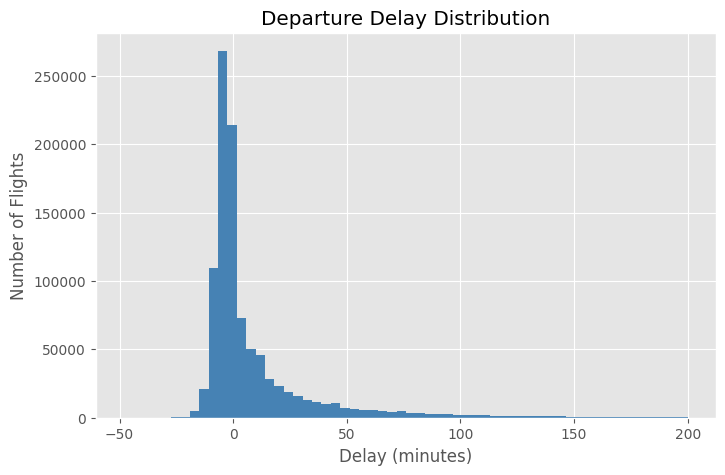

In [6]:
plt.figure(figsize=(8,5))
df[df['DEPARTURE_DELAY'].between(-50, 200)]['DEPARTURE_DELAY'].hist(bins=60, color='steelblue')
plt.title('Departure Delay Distribution')
plt.xlabel('Delay (minutes)')
plt.ylabel('Number of Flights')
plt.show()

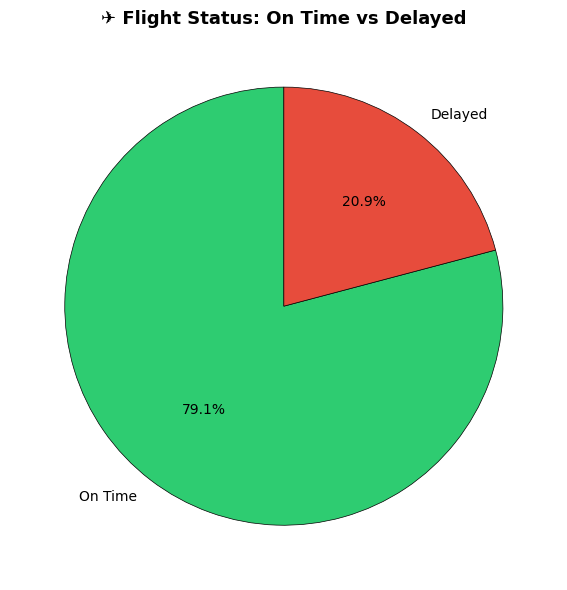

In [7]:
counts = df['IS_DELAYED'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, 
        labels=['On Time', 'Delayed'], 
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'],
        startangle=90,
        wedgeprops={'edgecolor': 'black'})

plt.title('✈️ Flight Status: On Time vs Delayed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

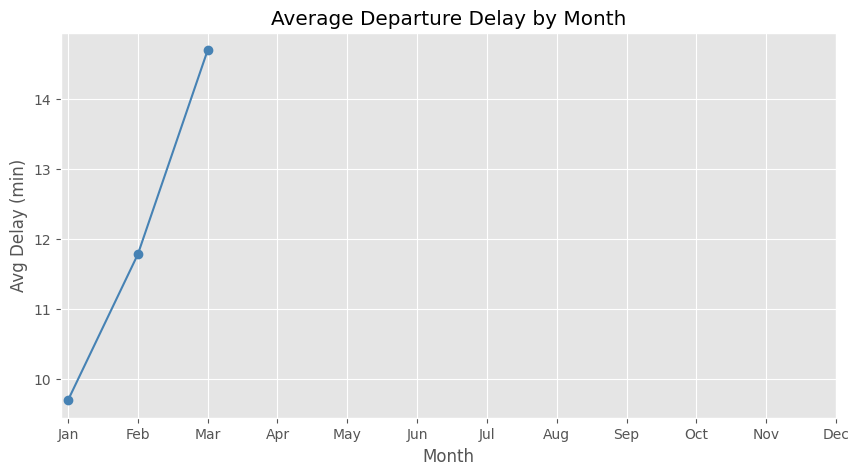

In [8]:
monthly = df.groupby('MONTH')['DEPARTURE_DELAY'].mean()

plt.figure(figsize=(10,5))
monthly.plot(kind='line', marker='o', color='steelblue')
plt.title('Average Departure Delay by Month')
plt.xlabel('Month')
plt.ylabel('Avg Delay (min)')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

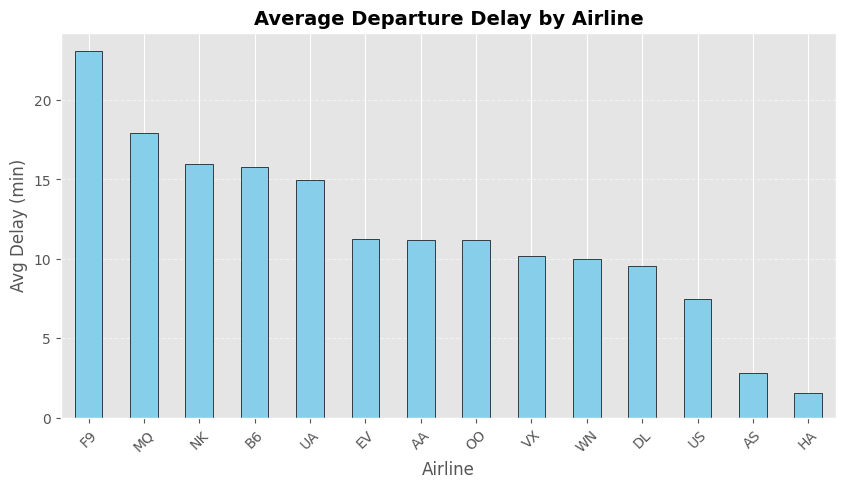

In [9]:
avg = df.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
avg.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Average Departure Delay by Airline', fontsize=14, fontweight='bold')
plt.xlabel('Airline')
plt.ylabel('Avg Delay (min)')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [10]:
cols = ['DEPARTURE_DELAY','ARRIVAL_DELAY','AIR_TIME','DISTANCE']
cols = [c for c in cols if c in df.columns]

print("Summary Statistics:")
print(df[cols].describe().round(2))

print("\nSkewness:")
print(df[cols].skew().round(2))

Summary Statistics:
       DEPARTURE_DELAY  ARRIVAL_DELAY    AIR_TIME    DISTANCE
count       1005504.00     1005504.00  1005504.00  1005504.00
mean             11.24           7.61      112.75      806.91
std              38.95          42.09       71.87      595.65
min             -61.00         -82.00        7.00       31.00
25%              -5.00         -12.00       60.00      369.00
50%              -1.00          -3.00       94.00      643.00
75%              11.00          12.00      144.00     1050.00
max            1988.00        1971.00      687.00     4983.00

Skewness:
DEPARTURE_DELAY    7.67
ARRIVAL_DELAY      6.44
AIR_TIME           1.43
DISTANCE           1.46
dtype: float64


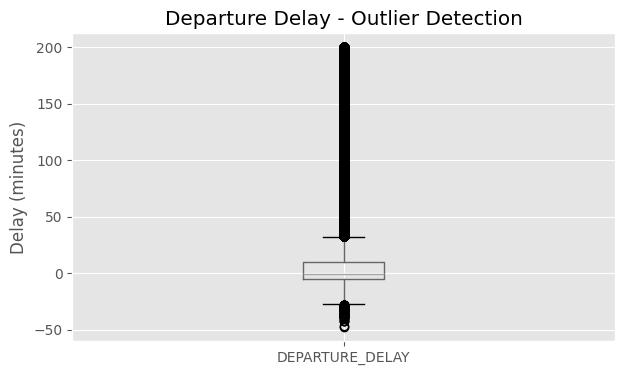

IQR = 16.00
Outlier range: below -29.0 or above 35.0


In [11]:
plt.figure(figsize=(7,4))
df[df['DEPARTURE_DELAY'].between(-50,200)].boxplot(column='DEPARTURE_DELAY')
plt.title('Departure Delay - Outlier Detection')
plt.ylabel('Delay (minutes)')
plt.show()

Q1 = df['DEPARTURE_DELAY'].quantile(0.25)
Q3 = df['DEPARTURE_DELAY'].quantile(0.75)
IQR = Q3 - Q1
print(f"IQR = {IQR:.2f}")
print(f"Outlier range: below {Q1 - 1.5*IQR:.1f} or above {Q3 + 1.5*IQR:.1f}")

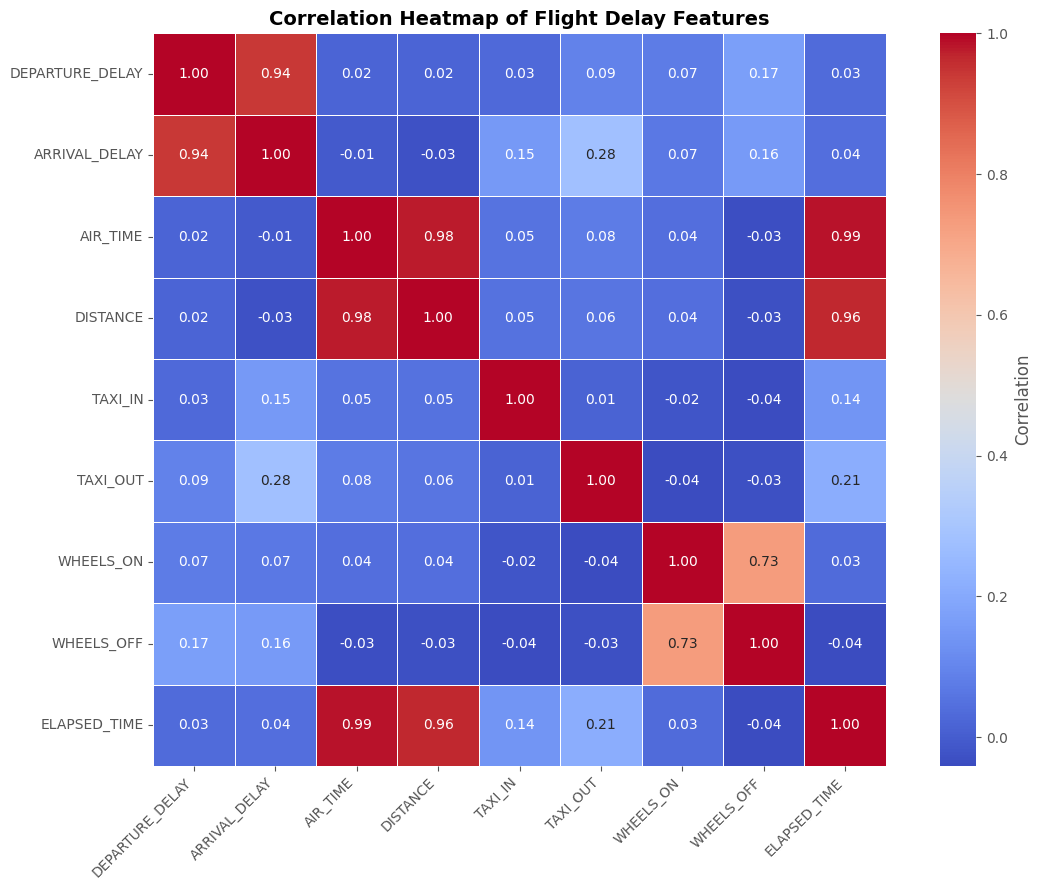

In [12]:
cols = ['DEPARTURE_DELAY','ARRIVAL_DELAY','AIR_TIME','DISTANCE',
        'TAXI_IN','TAXI_OUT','WHEELS_ON','WHEELS_OFF','ELAPSED_TIME']
cols = [c for c in cols if c in df.columns]

plt.figure(figsize=(12, 9))
sns.heatmap(df[cols].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            linewidths=0.5,
            square=True,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap of Flight Delay Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

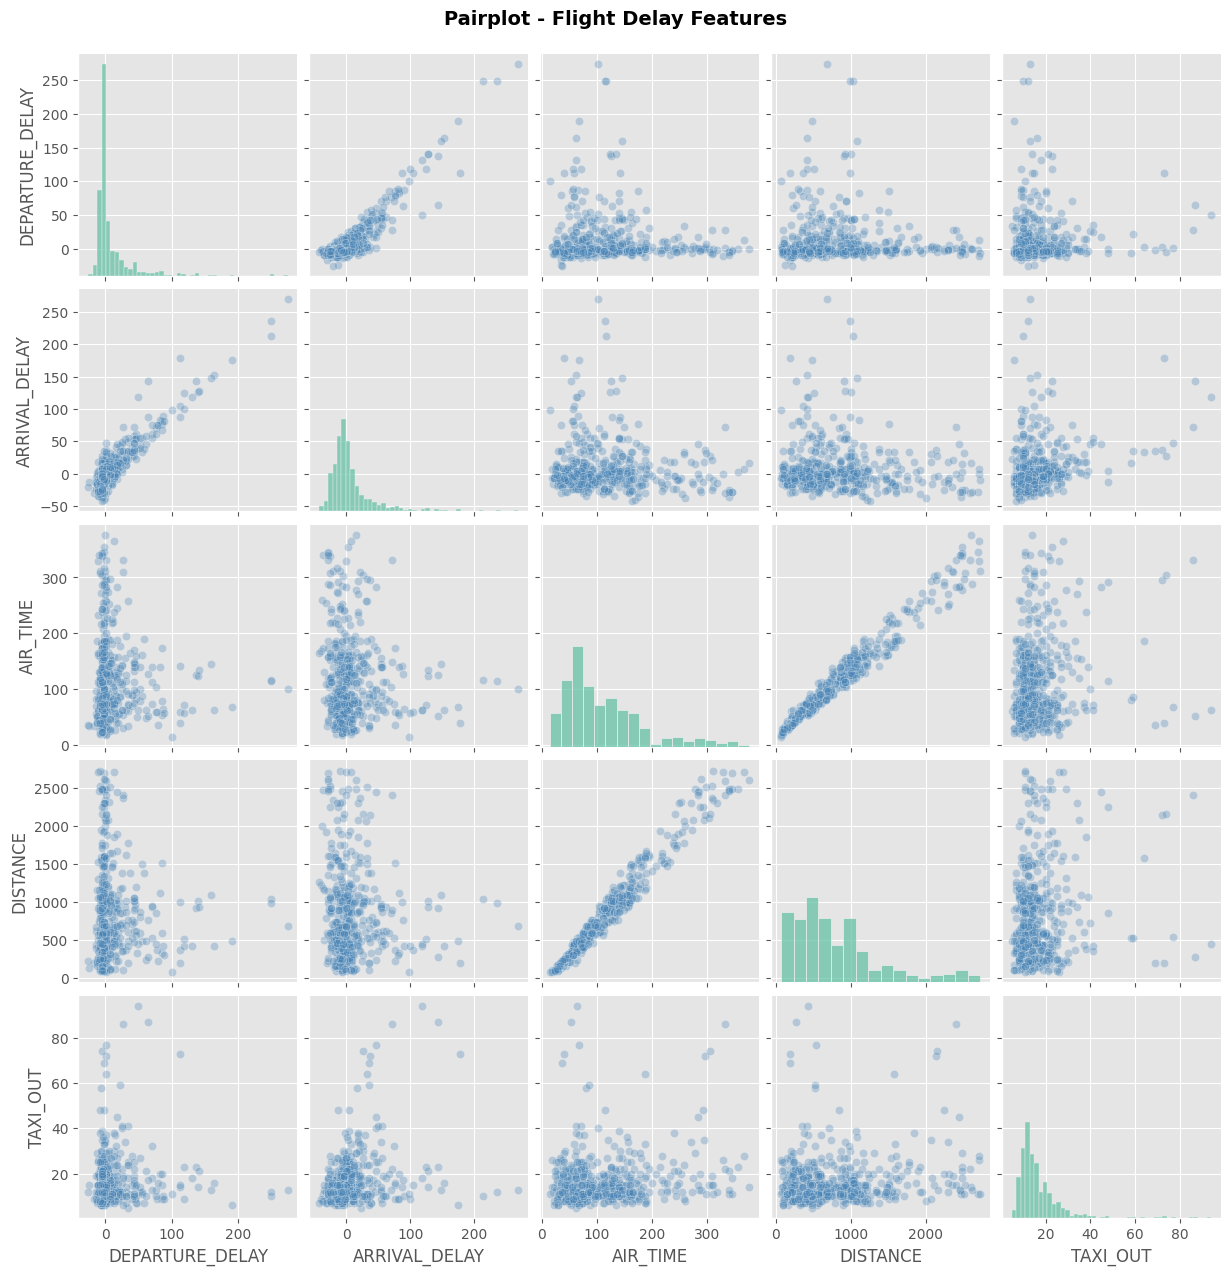

In [20]:
cols = ['DEPARTURE_DELAY','ARRIVAL_DELAY','AIR_TIME','DISTANCE','TAXI_OUT']
cols = [c for c in cols if c in df.columns]

sample = df[cols].dropna().sample(500, random_state=42)

sns.pairplot(sample, diag_kind='hist', plot_kws={'alpha':0.3, 'color':'steelblue'})
plt.suptitle('Pairplot - Flight Delay Features', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot.png', dpi=150)
plt.show()

In [21]:
aa = df[df['AIRLINE']=='AA']['DEPARTURE_DELAY'].dropna()
dl = df[df['AIRLINE']=='DL']['DEPARTURE_DELAY'].dropna()

t, p = stats.ttest_ind(aa, dl)
print("T-Test: AA vs DL Airline Delays")
print(f"T-statistic : {t:.4f}")
print(f"P-value     : {p:.6f}")
print("Result:", "Significant difference" if p < 0.05 else "No significant difference")

T-Test: AA vs DL Airline Delays
T-statistic : 8.7304
P-value     : 0.000000
Result: Significant difference


In [22]:
table = pd.crosstab(df['MONTH'], df['IS_DELAYED'])
chi2, p, dof, _ = stats.chi2_contingency(table)

print("Chi-Square Test: Month vs Delay")
print(f"Chi2    : {chi2:.4f}")
print(f"P-value : {p:.6f}")
print("Result:", "Month affects delay" if p < 0.05 else "No relation")

Chi-Square Test: Month vs Delay
Chi2    : 2441.3556
P-value : 0.000000
Result: Month affects delay


In [23]:
sample = df['DEPARTURE_DELAY'].dropna().sample(500, random_state=42)
stat, p = stats.shapiro(sample)

print("Shapiro-Wilk Normality Test")
print(f"Stat    : {stat:.4f}")
print(f"P-value : {p:.6f}")
print("Result:", "Not Normal" if p < 0.05 else "Normal")

Shapiro-Wilk Normality Test
Stat    : 0.5624
P-value : 0.000000
Result: Not Normal


LINEAR REGRESSION RESULTS
R² Score : 0.9434
MAE      : 7.25 min


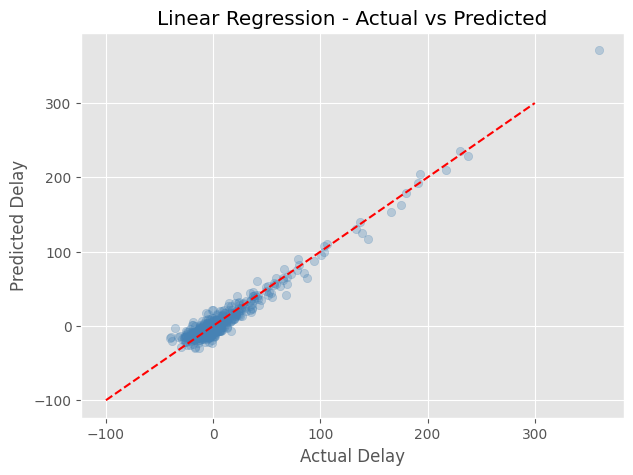

In [24]:
cols = ['DEPARTURE_DELAY','AIR_TIME','DISTANCE','TAXI_IN','TAXI_OUT']
cols = [c for c in cols if c in df.columns]

data = df[cols + ['ARRIVAL_DELAY']].dropna().sample(20000, random_state=42)
X = data[cols]
y = data['ARRIVAL_DELAY']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("LINEAR REGRESSION RESULTS")
print(f"R² Score : {r2_score(y_test, y_pred):.4f}")
print(f"MAE      : {mean_absolute_error(y_test, y_pred):.2f} min")

# Plot
plt.figure(figsize=(7,5))
plt.scatter(y_test[:500], y_pred[:500], alpha=0.3, color='steelblue')
plt.plot([-100,300],[-100,300],'r--')
plt.xlabel('Actual Delay')
plt.ylabel('Predicted Delay')
plt.title('Linear Regression - Actual vs Predicted')
plt.show()

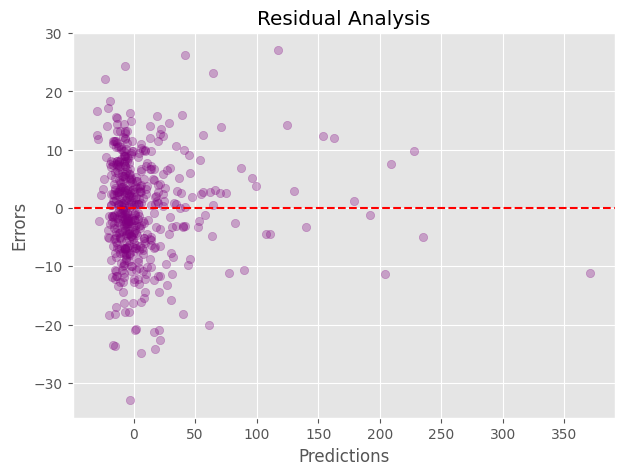

In [25]:
errors = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred[:500], errors[:500], alpha=0.3, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Analysis')
plt.xlabel('Predictions')
plt.ylabel('Errors')
plt.show()

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

     On Time       0.53      0.62      0.57      1981
     Delayed       0.55      0.46      0.50      2019

    accuracy                           0.54      4000
   macro avg       0.54      0.54      0.54      4000
weighted avg       0.54      0.54      0.54      4000



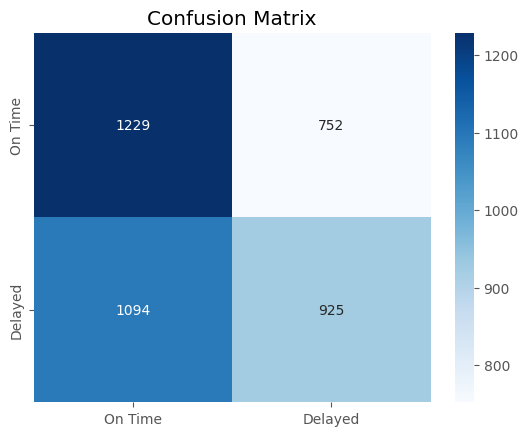

In [26]:
cols2 = ['AIR_TIME','DISTANCE','MONTH','TAXI_OUT']
cols2 = [c for c in cols2 if c in df.columns]

data2 = df[cols2 + ['IS_DELAYED']].dropna()

# Balance classes
c1 = data2[data2['IS_DELAYED']==1].sample(10000, random_state=42)
c0 = data2[data2['IS_DELAYED']==0].sample(10000, random_state=42)
balanced = pd.concat([c1, c0])

X = balanced[cols2]
y = balanced['IS_DELAYED']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("LOGISTIC REGRESSION RESULTS")
print(classification_report(y_test, y_pred, target_names=['On Time','Delayed']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time','Delayed'],
            yticklabels=['On Time','Delayed'])
plt.title('Confusion Matrix')
plt.show()